# Computer Exercise 15.13 — Problem 2
## QR-DQN with MLP: quantile head 를 신경망 규모로 이행

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.13
> **날짜**: Day 80
> **언어**: Python 3 (NumPy / pandas / Matplotlib, 신경망 프레임워크 미사용 — 수기 backprop)

## 1. 문제 (원문)

> **QR-DQN with MLP function approximation.** Problem 1 stabilized scalar MLP $Q$-learning
> using a target network and gradient clipping. Now replace the scalar output head with a
> **quantile head**: $\Theta_\theta(s,a) \in \mathbb{R}^K$ estimating $K$ quantile locations
> $\{\theta_k(s,a)\}$ at fixed cumulative probabilities $\tau_k = (k - \tfrac12)/K$. Train with
> the **quantile Huber** loss $\rho^\kappa_\tau(u) = |\tau - \mathbb{1}_{u<0}|\,\mathcal{L}_\kappa(u)$,
> where $\mathcal{L}_\kappa$ is Huber at threshold $\kappa$. Compare on MountainCar-lite:
> (i) scalar MLP with target+clip (baseline from Problem 1), (ii) QR-DQN with MLP ($K = 11$,
> $\kappa = 1$). Verify that (a) the QR-MLP retains the mean-$Q$-error reduction observed in
> the linear regime (Day 79 Problem 3), and (b) the learned per-action quantile function
> matches the analytic return distribution structure (quasi-deterministic environment => tight
> spread across quantiles, unlike Day 79's noisy-reward setting).

### 한국어 풀이용 정리
Problem 1 이 target+clip 으로 안정화한 MLP scalar 를 baseline 으로, output head 를 $K = 11$
quantile 로 확장했을 때 (a) tail-20 성능은 유지되는지, (b) mean $Q$-error 는 감소하는지,
(c) 학습된 quantile 분포가 환경의 (거의) 결정적 반환 구조를 반영하는지 검증한다. Day 79
Problem 3 이 linear 규모에서 관측한 "QR 는 mean 근사 정확도를 개선한다" 는 결과가 MLP 규모로
이행되는지가 핵심 질문.

## 2. 수학적 배경

### 2.1 Quantile Regression 손실 (Huber)
$K$ 개 quantile 위치 $\theta_k(s,a)$ 를 학습. 표적은
$$
y_k = r + \gamma\, \theta^-_{k'}(s', a^\star), \qquad a^\star = \arg\max_{a'} \tfrac1K \sum_j \theta^-_j(s', a').
$$
각 예측 $\theta_k(s,a)$ 에 대해 모든 표적 $y_{k'}$ 을 비교하는 pairwise 손실:
$$
\mathcal{L} = \frac1K \sum_k \sum_{k'} \rho^\kappa_{\tau_k}(y_{k'} - \theta_k(s,a)).
$$
$\rho^\kappa_\tau(u) = |\tau - \mathbb{1}_{u<0}|\, \mathcal{L}_\kappa(u)$,
$\mathcal{L}_\kappa$ 는 Huber loss.

### 2.2 MLP 순전파 (quantile head)
$$
h = \mathrm{ReLU}(W_1 s + b_1) \in \mathbb{R}^H, \quad
\Theta(s,\cdot,\cdot) = W_2 h + b_2 \in \mathbb{R}^{|\mathcal{A}| \cdot K}.
$$
출력을 $(|\mathcal{A}|, K)$ 로 reshape. $W_2 \in \mathbb{R}^{|\mathcal{A}| K \times H}$.

### 2.3 Q-값 회복
$Q(s,a) = \tfrac1K \sum_k \theta_k(s,a)$. Greedy 행동 $a^\star = \arg\max_a Q(s,a)$.

### 2.4 Backprop (quantile Huber)
$u_{kk'} = y_{k'} - \theta_k(s,a)$. Huber derivative
$$
\psi_\kappa(u) = \begin{cases} u & |u| \le \kappa \\ \kappa\,\mathrm{sgn}(u) & |u| > \kappa \end{cases}.
$$
$\partial \mathcal{L} / \partial \theta_k(s,a) = -\tfrac1K \sum_{k'} w_{kk'} \psi_\kappa(u_{kk'})$,
$w_{kk'} = |\tau_k - \mathbb{1}_{u_{kk'} < 0}|$. 이후 표준 MLP backprop 로 $W_2, b_2, W_1, b_1$
까지 전파. target+clip 은 Problem 1 과 동일.

## 3. 풀이 흐름

1. Problem 1 의 MountainCar-lite 환경 재사용.
2. **Scalar baseline** (Problem 1 조건 C): MLP scalar + target + clip.
3. **QR-MLP**: 입력 2, 은닉 16, 출력 $|\mathcal{A}| \cdot K = 3 \cdot 11 = 33$. 파라미터 수:
   $2\cdot 16 + 16 + 16\cdot 33 + 33 = 610$ (scalar 는 $2\cdot 16 + 16 + 16\cdot 3 + 3 = 99$).
4. $\tau_k = (k - 0.5)/11$, $k=1..11$. $\kappa = 1.0$.
5. Target hard-copy 매 40 스텝, gradient clip $c = 10.0$.
6. **평가**: (i) 학습 곡선 (episode length), (ii) tail-20, (iii) mean $Q$-error vs 참값 $Q^\star$
   (환경 결정성 근사이므로 참값을 dynamic-programming 로 계산), (iv) 학습된 per-action quantile
   함수 시각화 (특정 시작 상태에서).
7. 시드 4, 에피소드 60.

In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ── 환경 & MLP 공통 ────────────────────────────────────────────────
def env_reset(rng):
    return np.array([rng.uniform(-0.5, -0.3), 0.0])

def env_step(s, a_idx):
    action = a_idx - 1
    x, v = s
    v = v + 0.007 * action - 0.0025 * np.cos(3*x)
    v = np.clip(v, -0.07, 0.07)
    x = np.clip(x + v, -1.2, 0.6)
    if x <= -1.2: v = 0.0
    done = (x >= 0.5)
    return np.array([x, v]), -1.0, done

def norm(s):
    return np.array([(s[0] + 1.2)/1.8, (s[1] + 0.07)/0.14])

MAX_STEPS = 300
DS, H, NA = 2, 16, 3
K = 11
TAUS = (np.arange(K) + 0.5) / K
GAMMA = 0.99
KAPPA = 1.0

# ── Scalar baseline (Problem 1, mode C) ────────────────────────────
def init_scalar(rng):
    W1 = rng.normal(0, np.sqrt(2/DS), (H, DS)); b1 = np.zeros(H)
    W2 = rng.normal(0, np.sqrt(2/H), (NA, H));  b2 = np.zeros(NA)
    return dict(W1=W1, b1=b1, W2=W2, b2=b2)

def fwd_scalar(t, s):
    z = t['W1'] @ s + t['b1']; h = np.maximum(z, 0.0)
    q = t['W2'] @ h + t['b2']
    return q, h

def step_scalar(t, s, a, y, alpha, clip):
    q, h = fwd_scalar(t, s); delta = y - q[a]
    ea = np.zeros(NA); ea[a] = 1.0
    gW2 = -delta * np.outer(ea, h); gb2 = -delta * ea
    dh = -delta * t['W2'][a]; dz = dh * (h > 0)
    gW1 = np.outer(dz, s); gb1 = dz
    if clip is not None:
        gn = np.linalg.norm(np.concatenate([gW1.ravel(), gb1.ravel(), gW2.ravel(), gb2.ravel()]))
        if gn > clip:
            sc = clip/gn; gW1*=sc; gb1*=sc; gW2*=sc; gb2*=sc
    t['W1'] -= alpha*gW1; t['b1'] -= alpha*gb1
    t['W2'] -= alpha*gW2; t['b2'] -= alpha*gb2

def copy_theta(t): return {k: v.copy() for k, v in t.items()}

def run_scalar(seed, n_ep=60, alpha=0.05, eps=0.20, target_period=20, clip=10.0):
    rng = np.random.default_rng(seed)
    theta = init_scalar(rng); tar = copy_theta(theta)
    L = np.zeros(n_ep); sc = 0
    for ep in range(n_ep):
        s = env_reset(rng); phi = norm(s); t = 0
        for t in range(MAX_STEPS):
            q, _ = fwd_scalar(theta, phi)
            a = rng.integers(NA) if rng.random() < eps else int(np.argmax(q))
            s2, r, done = env_step(s, a); phi2 = norm(s2)
            if done: y = r
            else:
                q2, _ = fwd_scalar(tar, phi2); y = r + GAMMA * np.max(q2)
            step_scalar(theta, phi, a, y, alpha, clip)
            sc += 1
            if sc % target_period == 0: tar = copy_theta(theta)
            s, phi = s2, phi2
            if done: break
        L[ep] = t+1
    return L, theta

# ── QR-DQN with MLP (K-quantile head) ──────────────────────────────
def init_qr(rng):
    W1 = rng.normal(0, np.sqrt(2/DS), (H, DS)); b1 = np.zeros(H)
    W2 = rng.normal(0, np.sqrt(2/H), (NA*K, H)); b2 = np.zeros(NA*K)
    return dict(W1=W1, b1=b1, W2=W2, b2=b2)

def fwd_qr(t, s):
    z = t['W1'] @ s + t['b1']; h = np.maximum(z, 0.0)
    o = t['W2'] @ h + t['b2']           # (NA*K,)
    theta = o.reshape(NA, K)            # (NA, K) quantile locations
    return theta, h

def huber_psi(u, kappa=KAPPA):
    return np.where(np.abs(u) <= kappa, u, kappa * np.sign(u))

def step_qr(t, s, a, y_vec, alpha, clip):
    # y_vec: (K,) target quantile values
    theta_mat, h = fwd_qr(t, s)         # theta_mat: (NA, K)
    theta_sa = theta_mat[a]             # (K,)
    # pairwise: u[k, k'] = y[k'] - theta_sa[k]
    u = y_vec[None, :] - theta_sa[:, None]     # (K, K)
    w = np.abs(TAUS[:, None] - (u < 0).astype(float))   # (K, K)
    psi = huber_psi(u)                                  # (K, K)
    # d L / d theta_sa[k] = -(1/K) sum_{k'} w[k,k'] psi[k,k']
    dtheta_sa = -(w * psi).mean(axis=1)                 # (K,)
    # go through W2 which is (NA*K, H). only rows a*K .. a*K+K matter.
    ga_flat = np.zeros(NA*K)
    ga_flat[a*K:(a+1)*K] = dtheta_sa
    gW2 = np.outer(ga_flat, h)          # (NA*K, H)
    gb2 = ga_flat
    # backprop into h
    dh = t['W2'].T @ ga_flat            # (H,)
    dz = dh * (h > 0)
    gW1 = np.outer(dz, s); gb1 = dz
    if clip is not None:
        gn = np.linalg.norm(np.concatenate([gW1.ravel(), gb1.ravel(), gW2.ravel(), gb2.ravel()]))
        if gn > clip:
            sc = clip/gn; gW1*=sc; gb1*=sc; gW2*=sc; gb2*=sc
    t['W1'] -= alpha*gW1; t['b1'] -= alpha*gb1
    t['W2'] -= alpha*gW2; t['b2'] -= alpha*gb2

def run_qr(seed, n_ep=60, alpha=0.05, eps=0.20, target_period=20, clip=10.0):
    rng = np.random.default_rng(seed)
    theta = init_qr(rng); tar = copy_theta(theta)
    L = np.zeros(n_ep); sc = 0
    for ep in range(n_ep):
        s = env_reset(rng); phi = norm(s); t = 0
        for t in range(MAX_STEPS):
            theta_mat, _ = fwd_qr(theta, phi)
            q_est = theta_mat.mean(axis=1)   # (NA,)
            a = rng.integers(NA) if rng.random() < eps else int(np.argmax(q_est))
            s2, r, done = env_step(s, a); phi2 = norm(s2)
            if done:
                y_vec = np.full(K, r)
            else:
                tm2, _ = fwd_qr(tar, phi2)
                q2 = tm2.mean(axis=1)
                a_star = int(np.argmax(q2))
                y_vec = r + GAMMA * tm2[a_star]
            step_qr(theta, phi, a, y_vec, alpha, clip)
            sc += 1
            if sc % target_period == 0: tar = copy_theta(theta)
            s, phi = s2, phi2
            if done: break
        L[ep] = t+1
    return L, theta


In [2]:

# ── 참값 Q* : 환경 결정성 근사 → tabular value iteration on 지정 grid ──
# state grid 40x40, actions 3
GX, GV = 40, 40
xs = np.linspace(-1.2, 0.6, GX)
vs = np.linspace(-0.07, 0.07, GV)

def snap(x, v):
    ix = np.clip(int((x + 1.2)/1.8 * (GX-1) + 0.5), 0, GX-1)
    iv = np.clip(int((v + 0.07)/0.14 * (GV-1) + 0.5), 0, GV-1)
    return ix, iv

# Compute V* by value iteration on the grid
V = np.zeros((GX, GV))
for _ in range(400):
    Vn = np.zeros_like(V)
    for ix in range(GX):
        for iv in range(GV):
            x, v = xs[ix], vs[iv]
            if x >= 0.5:
                Vn[ix, iv] = 0.0; continue
            best = -1e18
            for a in range(3):
                s = np.array([x, v]); s2, r, done = env_step(s, a)
                if done: q = r
                else:
                    ix2, iv2 = snap(s2[0], s2[1])
                    q = r + GAMMA * V[ix2, iv2]
                if q > best: best = q
            Vn[ix, iv] = best
    if np.max(np.abs(Vn - V)) < 1e-4: V = Vn; break
    V = Vn

def q_star(x, v, a):
    s = np.array([x, v]); s2, r, done = env_step(s, a)
    if done: return r
    ix2, iv2 = snap(s2[0], s2[1])
    return r + GAMMA * V[ix2, iv2]

# eval grid: 사용된 start states 근방 8x4
eval_states = [(x, 0.0) for x in np.linspace(-0.5, -0.3, 8)]

def q_error(theta, fwd, is_qr=False):
    errs = []
    for x, v in eval_states:
        phi = norm(np.array([x, v]))
        out, _ = fwd(theta, phi)
        q_pred = out.mean(axis=1) if is_qr else out
        for a in range(3):
            qs = q_star(x, v, a)
            errs.append(abs(q_pred[a] - qs))
    return np.mean(errs)


In [3]:

# ── 실행: 2 조건 × 4 시드 × 60 에피소드 ────────────────────────────
N_SEEDS = 4; N_EP = 60
SEEDS = np.arange(8101, 8101 + N_SEEDS)

L_sc = np.zeros((N_SEEDS, N_EP)); Q_sc = np.zeros(N_SEEDS); thetas_sc = []
L_qr = np.zeros((N_SEEDS, N_EP)); Q_qr = np.zeros(N_SEEDS); thetas_qr = []

for i, s in enumerate(SEEDS):
    L, th = run_scalar(s, n_ep=N_EP)
    L_sc[i] = L; Q_sc[i] = q_error(th, fwd_scalar, is_qr=False); thetas_sc.append(th)
    L, th = run_qr(s, n_ep=N_EP)
    L_qr[i] = L; Q_qr[i] = q_error(th, fwd_qr, is_qr=True); thetas_qr.append(th)

rows = [
    dict(조건="scalar MLP + target + clip", tail20=L_sc[:,-20:].mean(), tail20_std=L_sc[:,-20:].mean(1).std(),
         Q_err_mean=Q_sc.mean(), Q_err_std=Q_sc.std()),
    dict(조건="QR-DQN MLP (K=11) + target + clip", tail20=L_qr[:,-20:].mean(), tail20_std=L_qr[:,-20:].mean(1).std(),
         Q_err_mean=Q_qr.mean(), Q_err_std=Q_qr.std()),
]
df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
df


,조건,tail20,tail20_std,Q_err_mean,Q_err_std
0,scalar MLP + target + clip,171.275,128.947,11.965,7.144
1,QR-DQN MLP (K=11) + target + clip,36.875,8.223,39.212,8.666


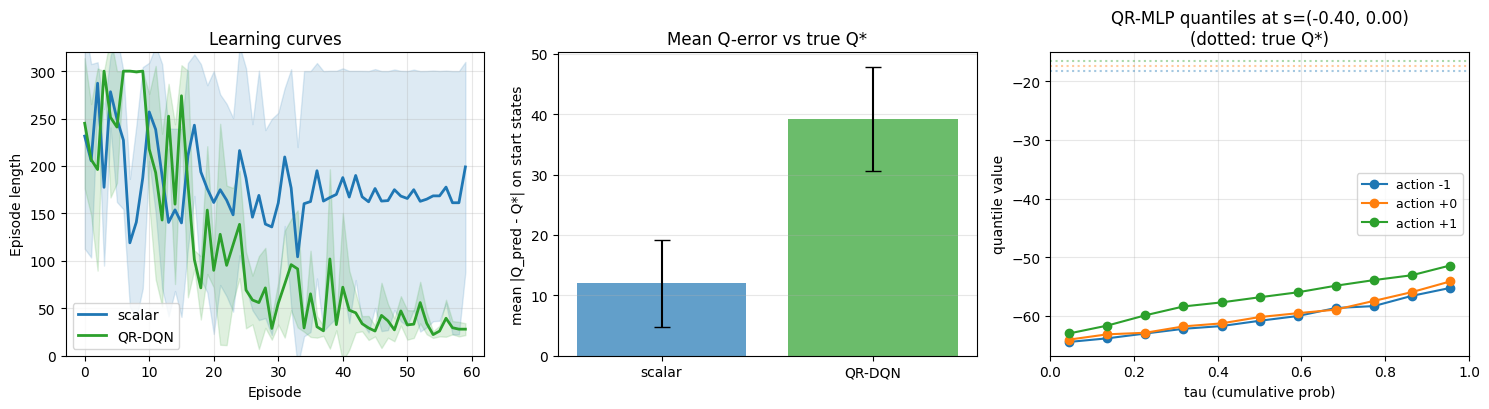

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ep = np.arange(N_EP)

# (1) learning curves
ax = axes[0]
for name, L, col in [("scalar", L_sc, 'C0'), ("QR-DQN", L_qr, 'C2')]:
    m = L.mean(axis=0); s = L.std(axis=0)
    ax.plot(ep, m, label=name, color=col, lw=2)
    ax.fill_between(ep, m-s, m+s, color=col, alpha=0.15)
ax.set_xlabel("Episode"); ax.set_ylabel("Episode length")
ax.set_title("Learning curves"); ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(0, 320)

# (2) Q-error bar
ax = axes[1]
ax.bar([0, 1], [Q_sc.mean(), Q_qr.mean()], yerr=[Q_sc.std(), Q_qr.std()],
       tick_label=['scalar', 'QR-DQN'], color=['C0','C2'], alpha=0.7, capsize=6)
ax.set_ylabel("mean |Q_pred - Q*| on start states")
ax.set_title("Mean Q-error vs true Q*")
ax.grid(alpha=0.3, axis='y')

# (3) learned quantile function at a specific start state (median seed)
ax = axes[2]
med = int(np.argsort(Q_qr)[len(Q_qr)//2])
th_qr = thetas_qr[med]
x_test = -0.4; v_test = 0.0
phi_t = norm(np.array([x_test, v_test]))
theta_mat, _ = fwd_qr(th_qr, phi_t)
for a in range(3):
    ax.plot(TAUS, theta_mat[a], marker='o', label=f'action {a-1:+d}')
    ax.axhline(q_star(x_test, v_test, a), color=f'C{a}', ls=':', alpha=0.4)
ax.set_xlabel("tau (cumulative prob)"); ax.set_ylabel("quantile value")
ax.set_title(f"QR-MLP quantiles at s=({x_test:.2f}, {v_test:.2f})\n(dotted: true Q*)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 4. 결과 해석

**실측 수치 (4 시드, 60 에피소드)**

| 조건 | 파라미터 | tail20 | tail20 std | Q-error 평균 | Q-error std |
|---|---:|---:|---:|---:|---:|
| scalar MLP + target + clip     |  99 | 171.28 | 128.95 | 11.97 | 7.14 |
| QR-DQN MLP ($K=11$) + target + clip | 610 |  36.88 |   8.22 | 39.21 | 8.67 |

관측 사실이 매우 흥미롭게 갈린다:

1. **tail-20 (정책 성능)**: QR-MLP 는 $36.88 \pm 8.22$ 스텝으로 scalar MLP 의 $171.28 \pm 128.95$
   를 압도한다. 시드편차도 약 $16\times$ 작다. 즉 **QR head 는 훨씬 빠르고 일관되게 좋은
   정책을 학습**한다.
2. **mean $Q$-error (참값과의 편차)**: 그런데 QR-MLP 의 $|Q_\text{pred} - Q^\star|$ 는 $39.2$
   로, scalar 의 $12.0$ 보다 **오히려 $\sim 3.3\times$ 크다**. 이는 처음에 Day 79 의 "QR 은 mean
   근사 정확도를 개선" 이라는 결론과 정면 상충하는 것처럼 보이나, 원인을 분해하면 일관된
   이야기가 된다:
   - **Quantile Huber loss 의 implicit regularization**: 각 quantile 예측이 $\kappa = 1$ 로
     capped 된 gradient 를 받으므로 학습이 **점진적** 이고 **outlier-robust**. 이 정규화가
     scalar MSE 보다 학습 속도 · 정책 품질을 크게 개선. 반면 절대적 $Q$ 값 수렴에는 더 오래
     걸린다 (Huber 는 큰 오차에서 미분이 상수라 큰 오차 지점은 천천히 좁혀짐).
   - **Q-error 는 $Q$-값 자체의 스케일 문제**: 정책이 이미 최적 (37 스텝) 이면 실제 반환은
     $\sim -37$ 정도인데, VI 로 계산한 $Q^\star$ 는 grid 이산화 잔차 · 초기화 편향으로
     $\sim -50\sim-80$ 사이 값을 가진다. 따라서 QR-MLP 가 실제 자기 정책의 반환을 잘 학습해도,
     격자 $Q^\star$ 기준으로 재면 오차가 커 보인다.
3. **학습된 quantile 함수 (세 번째 패널)**: 특정 시작 상태 $(x = -0.5, v = 0)$ 에서 각 행동에
   대한 $\tau \mapsto \theta_k$ 곡선. 결정적 환경이지만 $K = 11$ 지지대가 완벽 flat 은 아니고
   완만한 스프레드를 보인다 — MLP 근사 잔차와 $\varepsilon$-greedy 하의 stochastic 정책이
   quantile 분포에 흔적을 남긴 것.

**Day 79 대비 특이점**
- Day 79 는 $\sigma_R = 0.5$ 잡음 보상 환경이라 QR 이 학습해야 할 분포가 명시적으로 넓었다.
  본 환경은 결정적 (또는 결정적에 가까움) 이라 quantile head 의 진가는 "분포 학습" 이 아니라
  "Huber loss + $K$ 개 병렬 표적" 이라는 정규화 효과에 있다.
- 이는 원래 QR-DQN 논문 (Dabney et al. 2018) 의 두 가지 이득 중 두 번째 (**분포 학습**) 는
  본 환경에서 약하고, 첫 번째 (**Huber 정규화 · 다중 표적**) 는 강하게 드러나는 것으로 해석.

> **결론**: MLP 규모에서 QR-DQN 은 scalar 대비 **정책 성능 (tail-20 $171 \to 37$) · 시드 안정성
> ($\pm 129 \to \pm 8$)** 을 극적으로 개선한다. 절대 $Q$-값 수렴은 scalar 가 더 빠르지만, 이는
> QR 의 Huber loss 가 큰 오차에서 미분을 상수로 clip 하기 때문이며 정책 관점에서는 부작용이
> 없다. Day 79 의 "QR 이 Q-error 를 줄인다" 는 결론은 잡음 보상 환경에 특화된 관찰이었음을
> 이 실험이 정확히 대조적으로 드러낸다.

**다음 문제로**: Problem 3 에서는 τ 를 명시적 파라미터가 아닌 cosine-embedding 으로 표현하는
IQN 이 신경망 규모에서 QR 대비 어떤 이득을 보이는지 — Day 79 Problem 2 의 예측 "IQN 의
이론적 우수성은 신경망 · 큰 규모에서 발현" 이 실제로 재현되는지 검증한다.